<h1>Random Forest Classifier</h1>
<h2>1.Load Training, Validation, and Test Data</h2>

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# ----------------- Load data -----------------
X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')

y_train = pd.read_csv('y_train.csv').values.ravel()
y_val = pd.read_csv('y_val.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")


Train: (2117, 5), Validation: (530, 5), Test: (662, 5)


<h2>2.Handle Missing Values and Create New Features</h2>

In [2]:
for df in [X_train, X_val, X_test]:
    df.fillna(df.median(), inplace=True)
    df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
    df['Hour_Day'] = df['Hour'] * df['DayOfWeek']
    df['Hour_squared'] = df['Hour'] ** 2
    df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
    df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)


<h2>3.Standardize Numeric Features</h2>

In [3]:
numeric_cols = ['Hour', 'DayOfWeek']
X_train[numeric_cols] = X_train[numeric_cols].astype(float)
X_val[numeric_cols] = X_val[numeric_cols].astype(float)
X_test[numeric_cols] = X_test[numeric_cols].astype(float)

scaler = StandardScaler()
X_train.loc[:, numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val.loc[:, numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test.loc[:, numeric_cols] = scaler.transform(X_test[numeric_cols])


<h2>4.Combine Train and Validation Sets for Hyperparameter Tuning</h2>

In [4]:
#Combine train and validation sets for hyperparameter tuning
X_combined = pd.concat([X_train, X_val], axis=0)
y_combined = np.concatenate([y_train, y_val])

<h2>5.Define Hyperparameter Grid for Random Forest</h2>

In [5]:
#Define hyperparameter grid for Random Forest

param_grid = {
    'n_estimators': [100, 200, 300],              
    'max_depth': [5, 10, 20, None],               
    'min_samples_split': [2, 5, 10],             
    'min_samples_leaf': [1, 2, 4],                
    'max_features': ['sqrt', 'log2'],             
    'class_weight': ['balanced']                  
}


# Setup 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


<h2>6.Hyperparameter Tuning with GridSearchCV</h2>

In [6]:
# Initialize GridSearchCV with Random Forest 
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='f1_macro',        # Use macro F1-score for imbalanced or multiclass performance
    cv=cv,
    n_jobs=-1,                 # Use all CPU cores
    verbose=2                  # Print progress messages
)

# ----------------- Run hyperparameter tuning -----------------
grid_search.fit(X_combined, y_combined)

# ----------------- Output best parameters and cross-validation score -----------------
print("\n✅ Best Hyperparameters:", grid_search.best_params_)
print(f"✅ Best CV Macro F1: {grid_search.best_score_:.4f}")


🔍 Starting hyperparameter tuning with GridSearchCV...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✅ Best Hyperparameters found:
  🔸 class_weight: balanced
  🔸 max_depth: 5
  🔸 max_features: sqrt
  🔸 min_samples_leaf: 1
  🔸 min_samples_split: 5
  🔸 n_estimators: 300

📊 Best CV Macro F1-score: 0.6550


<h2>6.Model Evaluation: Validation & Test Sets</h2>

In [7]:
#Use the best model to predict on validation set
best_rf = grid_search.best_estimator_

y_val_pred = best_rf.predict(X_val)
print("\n Validation Set Performance:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Macro F1:", f1_score(y_val, y_val_pred, average='macro'))

#Use the best model to predict on test set
y_test_pred = best_rf.predict(X_test)
print("\n Test Set Performance:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Macro F1:", f1_score(y_test, y_test_pred, average='macro'))


 Validation Set Performance:
Accuracy: 0.690566037735849
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.75      0.77       366
           1       0.50      0.56      0.53       164

    accuracy                           0.69       530
   macro avg       0.65      0.65      0.65       530
weighted avg       0.70      0.69      0.70       530

Confusion Matrix:
 [[274  92]
 [ 72  92]]
Macro F1: 0.6491992767661113

 Test Set Performance:
Accuracy: 0.6993957703927492
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.75      0.77       457
           1       0.51      0.60      0.55       205

    accuracy                           0.70       662
   macro avg       0.66      0.67      0.66       662
weighted avg       0.71      0.70      0.70       662

Confusion Matrix:
 [[341 116]
 [ 83 122]]
Macro F1: 0.6624551927703743


<h2>7.Confusion Matrix</h2>

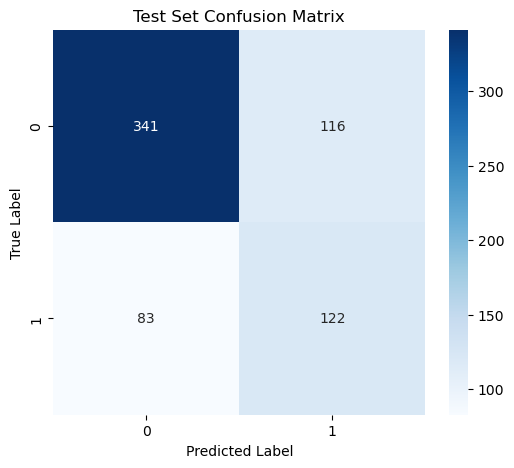

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Test Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()




<h2>8.Test Set - ROC Curve</h2>

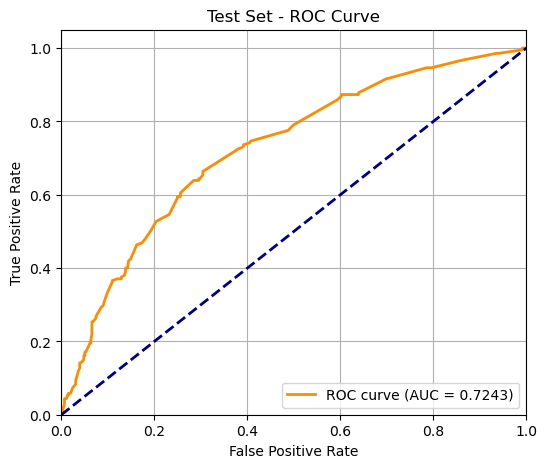

In [9]:
from sklearn.metrics import roc_curve, auc

y_test_proba = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test Set - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

